In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"
import tqdm
import torch
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from src.demo.plot import plot_confusion
from src.accentcl.models.accentcl import WhisperCLAccentModel

device = torch.device("cuda") if torch.cuda.is_available() else "cpu"

/data/mtseng/miniconda3/envs/accentcl/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
test_df = pd.read_csv('./samples/metadata.csv')
print(f"Loaded test dataset with {len(test_df)} samples.")

Loaded test dataset with 70 samples.


In [3]:
model_checkpoints = {
    "AccentCL-Base": "./checkpoints/accentcl_base.pt",
    "AccentCL + Spanish": "./checkpoints/accentcl_spanish.pt",
    "AccentCL + Spanish + Chinese": "./checkpoints/accentcl_spanish_chinese.pt",
}

In [4]:
results = defaultdict(lambda: defaultdict(list))
label2ids = {}
with torch.no_grad():
    for model_name, checkpoint_path in model_checkpoints.items():
        print(f"Loading model: {model_name} from {checkpoint_path}")
        model = WhisperCLAccentModel.from_checkpoint(checkpoint_path, device=device)
        model.eval()
        for _, row in tqdm.tqdm(test_df.iterrows(), total=len(test_df)):
            audio_path = row['audio_path']
            accent = row['accent']
            wav, _ = librosa.load(audio_path, sr=16000)
            audio_tensor = torch.tensor(wav).unsqueeze(0).to(device)
            
            pred_labels, logits, _ = model.predict(audio_tensor, return_feature=False)
            results[model_name][accent].append(pred_labels[0])
        label2ids[model_name] = model.label2id
        print('-' * 50)

Loading model: AccentCL-Base from ./checkpoints/accentcl_base.pt


100%|██████████| 70/70 [00:22<00:00,  3.12it/s]


--------------------------------------------------
Loading model: AccentCL + Spanish from ./checkpoints/accentcl_spanish.pt


100%|██████████| 70/70 [00:21<00:00,  3.22it/s]


--------------------------------------------------
Loading model: AccentCL + Spanish + Chinese from ./checkpoints/accentcl_spanish_chinese.pt


100%|██████████| 70/70 [00:24<00:00,  2.83it/s]

--------------------------------------------------


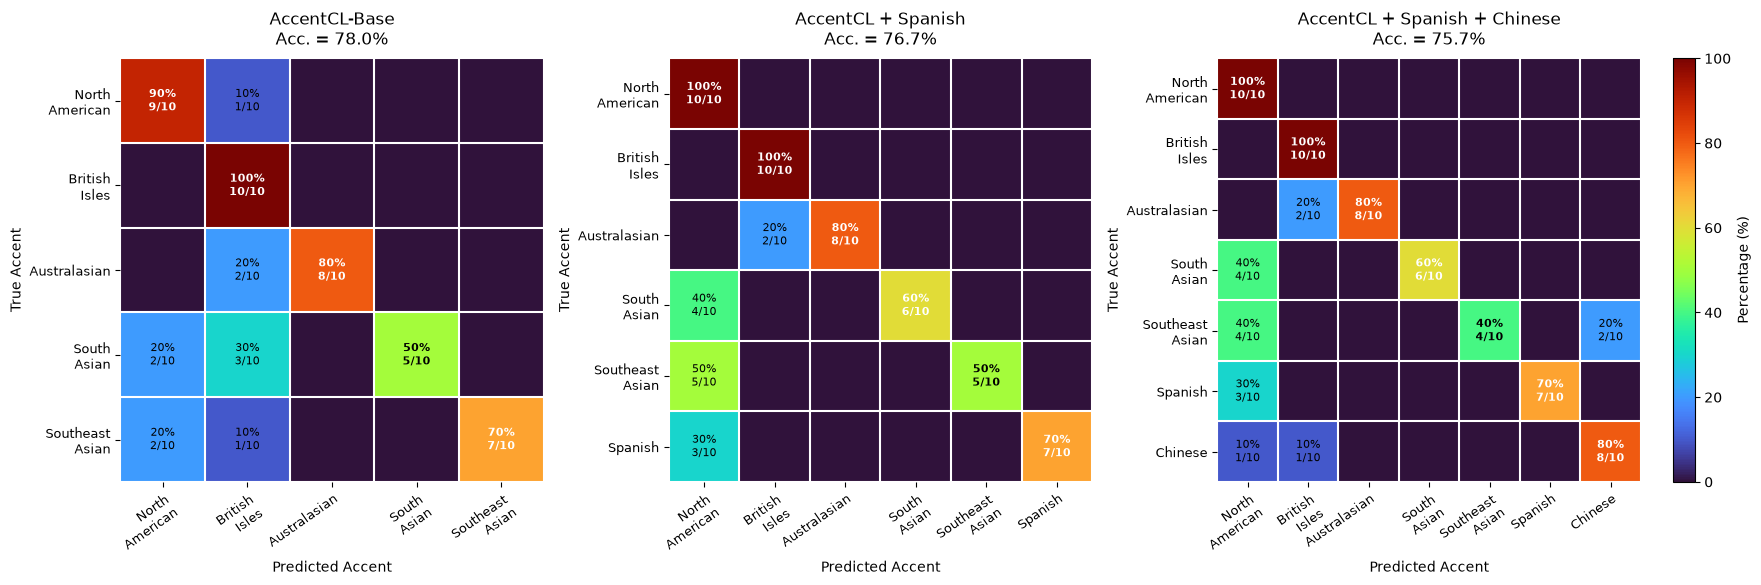

In [5]:
_ = plot_confusion(
    results,
    label2ids,
    normalize=True
)